In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import lick as lk
from matplotloom import Loom
from tqdm import tqdm
from joblib import Parallel, delayed
import re
import matplotlib.cm as cm
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import Bbox
import matplotlib.gridspec as gridspec
import os

In [2]:
gconst = 6.67430e-8
clight = 2.99792458e10
solar = 1.98847e33
lencgs2code = (clight**2)/(solar*gconst)
masscgs2code = (1.0e0/solar)
rhocgs2code = (masscgs2code/lencgs2code**3)
tcgs2code = (clight**3)/(solar*gconst)
mu_0 = 1.25663706212e-6
amp2code = (mu_0*1.0e5*masscgs2code*lencgs2code)**(0.5e0)/tcgs2code
gauss2code = 1.0e-1*masscgs2code/amp2code/tcgs2code**2
energycgs2code = (1.0E0/clight**2)
me2 = 9.1093837015e-28*masscgs2code
mb2 = 1.66053906660e-24*masscgs2code
ye = 0.5e0
h_bar = (1.054571817e-27)*(lencgs2code**2*masscgs2code/tcgs2code)
amax = (me2**4)/(2.4e1*np.pi**2*h_bar**3)
bmax = (mb2*me2**3)/(3.0e0*np.pi**2*h_bar**3*ye)

In [3]:
irho = 0
ivx = 1
ivy = 2
ivz = 3
itau = 4
ihe4 = 5
ic12 = 6
io16 = 7
ine20 = 8
img24 = 9
isi28 = 10
ini56 = 11
iye2 = 12
iturbq = 13
iscaG1 = 14
iscaG2 = 15

In [4]:
def parse_cumc3d_detonations(file_path):
    times, xs, zs = [], [], []

    time_pattern = re.compile(r"Occured at\s*=\s*(?P<time>[\d\.eE\+-]+)")
    coords_pattern = re.compile(r"Found deton at\s*(?P<x>\d+)\s+(?P<z>\d+)")

    current_time = None

    with open(file_path, "r") as f:
        for line in f:
            cleaned = line.strip()

            # Catch the detonation timestamp
            time_match = time_pattern.search(cleaned)
            if time_match:
                current_time = float(time_match.group("time"))
                continue

            # Catch the corresponding spatial grid coordinates
            coords_match = coords_pattern.search(cleaned)
            if coords_match and current_time is not None:
                times.append(current_time)
                xs.append(int(coords_match.group("x")))
                zs.append(int(coords_match.group("z")))
                current_time = None  # Reset state

    return np.array(times), np.array(xs), np.array(zs)

def map_times_to_closest_indices(detonation_times, target_time_axis):
    """Maps an array of detonation times to the closest indices of a target time axis."""
    target_time_axis = np.asarray(target_time_axis)
    detonation_times = np.asarray(detonation_times)

    # Find the insertion index where each detonation time would fall
    idx = np.searchsorted(target_time_axis, detonation_times)

    # Clip indices to safely look at [idx - 1] and [idx] without IndexError.
    # This also naturally handles edge cases where detonation times are out of bounds.
    clipped_idx = np.clip(idx, 1, len(target_time_axis) - 1)

    # Calculate distances to the time step before and the time step after
    dist_left = detonation_times - target_time_axis[clipped_idx - 1]
    dist_right = target_time_axis[clipped_idx] - detonation_times

    # If the left neighbor is closer, choose clipped_idx - 1, otherwise clipped_idx
    closest_indices = np.where(dist_left < dist_right, clipped_idx - 1, clipped_idx)

    return closest_indices

In [5]:
def read_star(working_directory):
    x1f = np.loadtxt(working_directory+'/hydro_x1_fgrid.dat')
    x1f = x1f [3:-3] # Remove BC
    x1c = (x1f[1:]+x1f[:-1])/2 #mid pt
    x3f = np.loadtxt(working_directory+'/hydro_x3_fgrid.dat')
    x3f = x3f [3:-3] # Remove BC
    x3c = (x3f[1:]+x3f[:-1])/2 #mid pt
    rho = np.loadtxt(working_directory+'/hydro_rho.dat')
    Aphi = np.loadtxt(working_directory+'/hydro_Aphi.dat')
    vphi = np.loadtxt(working_directory+'/hydro_vphi.dat')
    return x1f, x1c, x3f, x3c, rho, Aphi, vphi

def parse_path(path):
    axis_ratio = float(re.search(r'AxisRatio_([0-9.]+)', path).group(1))
    mass = float(re.search(r'mass_([0-9.]+)', path).group(1))
    return axis_ratio, mass

def find_times(path):
    files = []
    working_directory = path+'/outfile'
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1
    times = []
    for t in range(n):
        filename = path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        times.append(f['time'][0]/tcgs2code)
        f.close()
    return np.array(times)
    

In [6]:
data_paths = sorted(glob("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_*_AxisRatio_*"))[::-1]
data_paths = sorted(data_paths, key=lambda x: (-parse_path(x)[0], parse_path(x)[1]))

In [7]:
data_paths.append("/home/cnchong/Codes/cumc3d/model/Type_Ia")

In [8]:
req = np.array([2226.5435038 , 2931.45458253, 2446.35563511, 1930.79000826,
       1923.28600474, 1815.02041469, 2604.67542559, 1662.12581703,
       1620.22094116, 2983.32328168, 1790.31427217, 1812.45432216])
masses = np.array([1.37718716, 1.41225941, 1.5333452 , 1.65260647, 1.6563158 ,
       1.69271405, 1.63638974, 1.98545807, 2.03663921, 1.82438131,
       2.78735779, 2.86254625])
ratios = np.array([1.000, 0.737, 0.737, 0.737, 0.737, 0.737, 0.629, 0.629, 0.629, 0.479,0.479,0.479])

In [9]:
rotating = [0,1,2,6,9]
magnetised = [0,5,8,11]
mixed = [0,3,4,7,10]
mm = [3,4,5,7,8,10,11]
RB = [1,2,3,4,5]
B_flag = [1]*12
for index in [0,1,2,6,9]:
    B_flag[index] = 0
names = ["1.000","0.737R","0.737V","0.737RB","0.737VB","0.737B","0.629V","0.629VB","0.629B","0.479V","0.479VB","0.479B"] 
# names = ["Base","R","0.737V","0.737RB","0.737VB","0.737B","0.629V","0.629VB","0.629B","V","VB","B"]
color_points = ['black', 'magenta', 'red', 'green', 'purple', 'blue', 'red', 'purple', 'blue', 'red', 'purple', 'blue']


Matter escapes from the simulation domain


KeyError: "Unable to open object (object 'detonations' doesn't exist)"

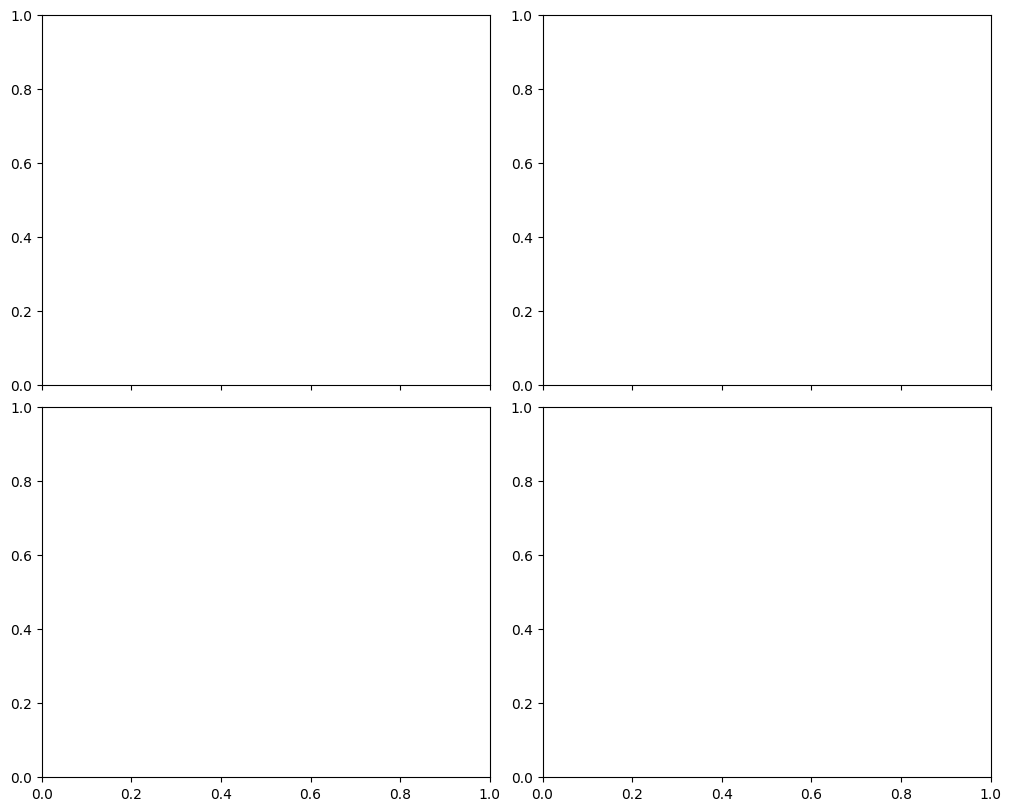

In [10]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, layout='constrained')
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_mass_CO = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []
final_mass_he = []
fraction_sum = []

for i in [0]:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True
        else:
            if t == n-1:
                table_time.append(0)

    KE = np.array(KE)
    RKE = np.array(RKE)
    ME = np.array(ME)
    star_masses = np.array(star_masses)
    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    He_fraction = np.array(mass_dict['He'])/star_masses
    CO_fraction = (np.array(mass_dict['C'])+np.array(mass_dict['O']))/star_masses
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    fraction_sum.append((IME_fraction+Ni_fraction+He_fraction+CO_fraction)[-1])

    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_CO.append((np.array(mass_dict['C']) + np.array(mass_dict['O']))[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg']) + np.array(mass_dict['Si']))[-1]/solar)
    final_mass_he.append(np.array(mass_dict['He'])[-1]/solar)
    
    # Change variable to what you wanna plot
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_He = np.interp(dett, times, He_fraction)
    dett_y_CO = np.interp(dett, times, CO_fraction)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_He = np.interp(escape_time, times, He_fraction)
        escape_time_y_CO = np.interp(escape_time, times, CO_fraction)
    
    if i == 0:
        # Subplot 0,0
        axs[0,0].plot(times, He_fraction, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[0,0].scatter(dett, dett_y_He, color='black', rasterized=True)
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_He, color='black', marker="^", rasterized=True)

        # Subplot 0,1
        axs[0,1].plot(times, CO_fraction, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[0,1].scatter(dett, dett_y_CO, color='black', rasterized=True)
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_CO, color='black', marker="^", rasterized=True)

        # Subplot 1,0
        axs[1,0].plot(times, Ni_fraction, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[1,0].scatter(dett, dett_y_Ni, color='black', rasterized=True)
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_Ni, color='black', marker="^", rasterized=True)

        # Subplot 1,1
        axs[1,1].plot(times, IME_fraction, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[1,1].scatter(dett, dett_y_IME, color='black', rasterized=True)
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_IME, color='black', marker="^", rasterized=True)
    else:
        # --- Subplot [0, 0] ---
        line_00, = axs[0,0].plot(times, He_fraction, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        axs[0,0].scatter(dett, dett_y_He, color=color_00, rasterized=True)
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_He, marker="^", color=color_00, rasterized=True)

        # --- Subplot [0, 1] ---
        line_01, = axs[0,1].plot(times, CO_fraction, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_01 = line_01.get_color()
        axs[0,1].scatter(dett, dett_y_CO, color=color_01, rasterized=True)
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_CO, marker="^", color=color_01, rasterized=True)

        # --- Subplot [1, 0] ---
        line_10, = axs[1,0].plot(times, Ni_fraction, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_10 = line_10.get_color()
        axs[1,0].scatter(dett, dett_y_Ni, color=color_10, rasterized=True)
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_Ni, marker="^", color=color_10, rasterized=True)

        # --- Subplot [1, 1] ---
        line_11, = axs[1,1].plot(times, IME_fraction, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_11 = line_11.get_color()
        axs[1,1].scatter(dett, dett_y_IME, color=color_11, rasterized=True)
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_IME, marker="^", color=color_11, rasterized=True)


# --- Labels and Titles Configuration ---
axs[0,0].set_ylabel(r'$M_\text{He}/M_D$', fontsize=15)
axs[0,0].set_title("Mass fraction of ${}^{4}$He", fontsize=15)
axs[0,0].legend()

axs[0,1].set_ylabel(r'$M_\text{CO}/M_D$', fontsize=15)
axs[0,1].set_title(r"Mass fraction of ${}^{12}$C+${}^{16}$O", fontsize=15)

axs[1,0].set_xlabel('Time (s)', fontsize=15)
axs[1,0].set_ylabel(r'$M_\text{Ni}/M_D$', fontsize=15)
axs[1,0].set_title("Mass fraction of ${}^{56}$Ni", fontsize=15)

axs[1,1].set_xlabel('Time (s)', fontsize=15)
axs[1,1].set_ylabel(r'$M_\text{IME}/M_D$', fontsize=15)
axs[1,1].set_title("Mass fraction of IMEs", fontsize=15)

plt.suptitle('Nucleosynthesis', fontsize=15)
# plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/nucleo.pdf',transparent=True)

In [11]:
plt.plot(np.diff(star_masses/solar))
de = np.where(np.abs(np.diff(star_masses/solar))>1e-4)[0]
plt.scatter(de, np.diff(star_masses/solar)[de])

TypeError: unsupported operand type(s) for /: 'list' and 'float'

In [31]:
de

array([ 9, 10, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87,
       88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [64]:
exp_data = np.vstack(([1,2,3,4,5,6,7,8,9,10,11,12],mass_in_domain,final_mass_he,final_mass_CO,final_mass_ni,final_mass_ime,final_KE,final_RKE,final_ME, table_time))
np.savetxt("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/exp_data.dat",exp_data)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 12 and the array at index 1 has size 4

ValueError: x and y must be the same size

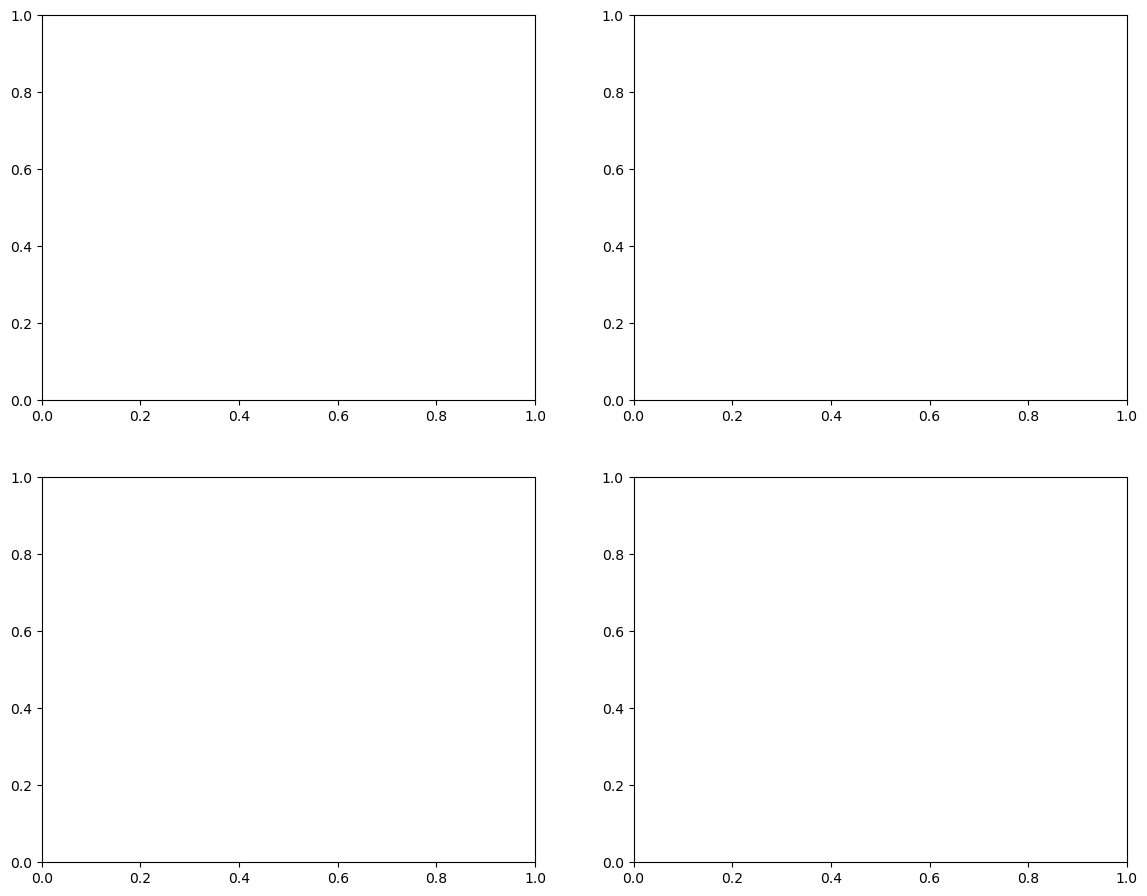

In [63]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

# Define the exact thickness requested for the hollow dot borders
stroke_thickness = 1.5

# ====================================================
# ROW 1, COL 1: He fraction (First plot with legend)
# ====================================================
ax_he = axs[0, 0]
ax_he.scatter(ratios, np.array(final_mass_he) / np.array(mass_in_domain), 
             facecolors='none', edgecolors=color_points, linewidths=stroke_thickness)
ax_he.invert_xaxis()
ax_he.set_xlabel(r'$\mathfrak{R}$', fontsize=15)
ax_he.set_ylabel(r'$M_\text{He}/M_D$', fontsize=15)
ax_he.set_title('He fraction against Axis Ratio', fontsize=15)

# Legend elements matching the 1.5 thickness
ax_he.scatter([], [], facecolors='none', edgecolors='black', linewidths=stroke_thickness, label='1.000')
ax_he.scatter([], [], facecolors='none', edgecolors='blue', linewidths=stroke_thickness, label='Purely Magnetic')
ax_he.scatter([], [], facecolors='none', edgecolors='purple', linewidths=stroke_thickness, label='Mixed V')
ax_he.scatter([], [], facecolors='none', edgecolors='green', linewidths=stroke_thickness, label='Mixed R')
ax_he.scatter([], [], facecolors='none', edgecolors='red', linewidths=stroke_thickness, label='Purely V')
ax_he.scatter([], [], facecolors='none', edgecolors='magenta', linewidths=stroke_thickness, label='Purely R')
ax_he.legend()

# ====================================================
# ROW 1, COL 2: CO fraction
# ====================================================
ax_co = axs[0, 1]
ax_co.scatter(ratios, np.array(final_mass_CO) / np.array(mass_in_domain), 
             facecolors='none', edgecolors=color_points, linewidths=stroke_thickness)
ax_co.invert_xaxis()
ax_co.set_xlabel(r'$\mathfrak{R}$', fontsize=15)
ax_co.set_ylabel(r'$M_\text{CO}/M_D$', fontsize=15)
ax_co.set_title('CO fraction against Axis Ratio', fontsize=15)

# ====================================================
# ROW 2, COL 1: Ni fraction
# ====================================================
ax_ni = axs[1, 0]
ax_ni.scatter(ratios, np.array(final_mass_ni) / np.array(mass_in_domain), 
             facecolors='none', edgecolors=color_points, linewidths=stroke_thickness)
ax_ni.invert_xaxis()
ax_ni.set_xlabel(r'$\mathfrak{R}$', fontsize=15)
ax_ni.set_ylabel(r'$M_\text{Ni}/M_D$', fontsize=15)
ax_ni.set_title('Ni fraction against Axis Ratio', fontsize=15)

# ====================================================
# ROW 2, COL 2: IME fraction
# ====================================================
ax_ime = axs[1, 1]
ax_ime.scatter(ratios, np.array(final_mass_ime) / np.array(mass_in_domain), 
             facecolors='none', edgecolors=color_points, linewidths=stroke_thickness)
ax_ime.invert_xaxis()
ax_ime.set_xlabel(r'$\mathfrak{R}$', fontsize=15)
ax_ime.set_ylabel(r'$M_\text{IME}/M_D$', fontsize=15)
ax_ime.set_title('IME fraction against Axis Ratio', fontsize=15)

# ====================================================
# Global Adjustments
# ====================================================
fig.suptitle('Summary of Nucleosynthesis', fontsize=15, y=0.98)

plt.tight_layout()
# plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/nu_result.pdf")
plt.show()

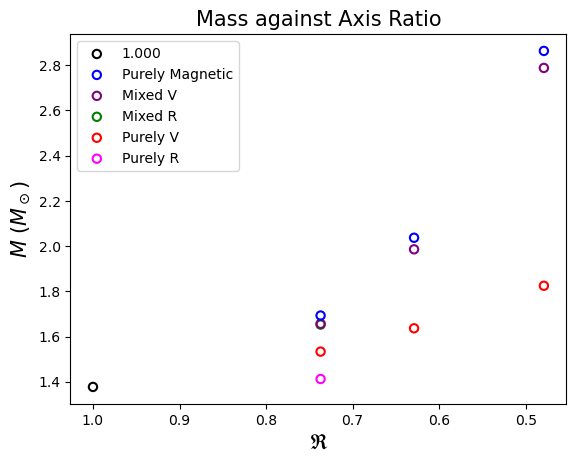

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Set the line thickness for the hollow dots
stroke_thickness = 1.5

# Main scatter plot with hollow dots
plt.scatter(ratios, masses, facecolors='none', edgecolors=color_points, linewidths=stroke_thickness)

# Invert axis and labels
plt.gca().invert_xaxis()
plt.xlabel(r'$\mathfrak{R}$', fontsize=15)
plt.ylabel(r'$M$ ($M_\odot$)', fontsize=15)
plt.title('Mass against Axis Ratio', fontsize=15)

# Hollow legend placeholders (font size remains default)
plt.scatter([], [], facecolors='none', edgecolors='black', linewidths=stroke_thickness, label='1.000')
plt.scatter([], [], facecolors='none', edgecolors='blue', linewidths=stroke_thickness, label='Purely Magnetic')
plt.scatter([], [], facecolors='none', edgecolors='purple', linewidths=stroke_thickness, label='Mixed V')
plt.scatter([], [], facecolors='none', edgecolors='green', linewidths=stroke_thickness, label='Mixed R')
plt.scatter([], [], facecolors='none', edgecolors='red', linewidths=stroke_thickness, label='Purely V')
plt.scatter([], [], facecolors='none', edgecolors='magenta', linewidths=stroke_thickness, label='Purely R')

plt.legend()

# Save the figure
# plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/MA.pdf")
plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/MA.pdf", transparent = True)
plt.show()

Matter escapes from the simulation domain


/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/167282331.py:146: RuntimeWarning: invalid value encountered in divide
  axs[0,1].plot(times, RKE/RKE[0], linestyle='--', color='black')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/167282331.py:147: RuntimeWarning: invalid value encountered in divide
  axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color='black', rasterized=True)
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/167282331.py:149: RuntimeWarning: invalid value encountered in scalar divide
  axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], color='black', marker="^", rasterized=True)


Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain


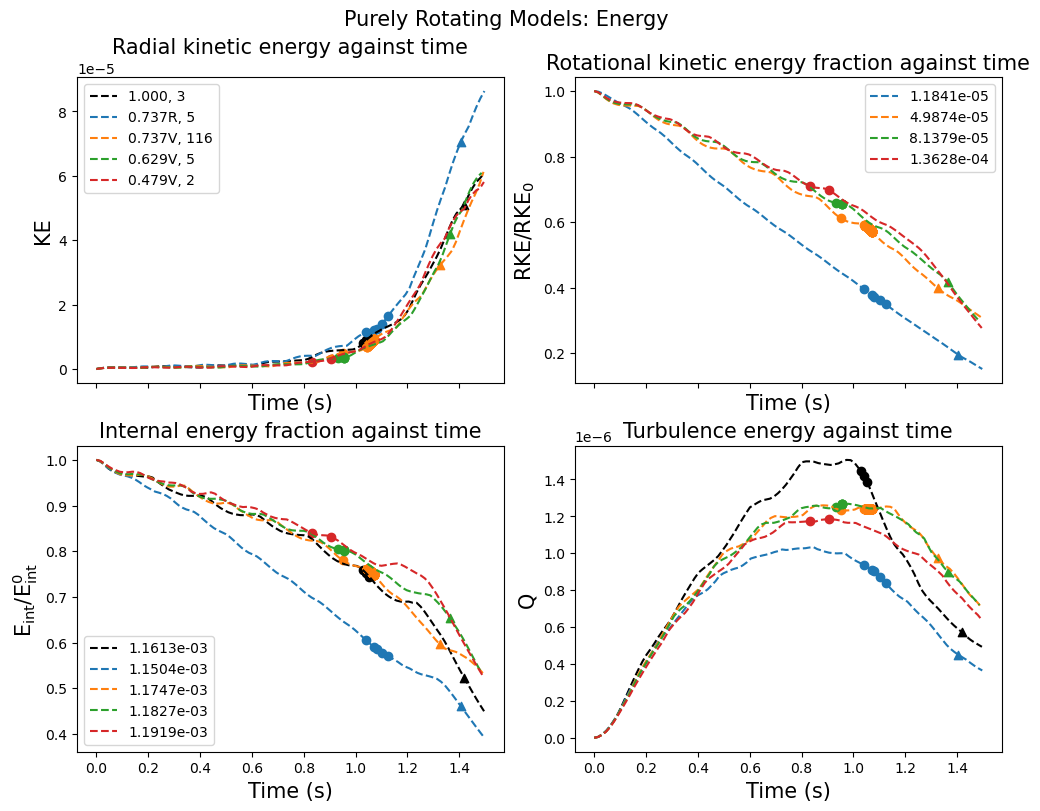

In [18]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, layout='constrained')
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_mass_CO = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []
final_mass_he = []

for i in rotating:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    int_E = []
    turbE = []
    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T
        eps = f['epsilon'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        q = primitive[iturbq,1:-1,1,1:-1]/energycgs2code
        epsilon = eps[1:-1,1,1:-1]/energycgs2code
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        int_E.append(np.sum(dens*epsilon*vol))
        turbE.append(np.sum(dens*q*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True
        else:
            if t == n-1:
                table_time.append(0)

    star_masses = np.array(star_masses)
    unit = star_masses*clight**2
    KE = np.array(KE)/unit
    RKE = np.array(RKE)/unit
    ME = np.array(ME)/unit
    int_E = np.array(int_E)/unit
    turbE = np.array(turbE)/unit
    
    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    He_fraction = np.array(mass_dict['He'])/star_masses
    CO_fraction = (np.array(mass_dict['C'])+np.array(mass_dict['O']))/star_masses
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_CO.append(np.array(mass_dict['C']+mass_dict['O'])[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
    final_mass_he.append(np.array(mass_dict['He'])[-1]/solar)
    
    # Detonation interpolation maps
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_ME = np.interp(dett, times, ME)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_He = np.interp(dett, times, He_fraction)
    dett_y_CO = np.interp(dett, times, CO_fraction)
    dett_y_int_E = np.interp(dett, times, int_E)
    dett_y_turbE = np.interp(dett, times, turbE)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_ME = np.interp(escape_time, times, ME)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_He = np.interp(escape_time, times, He_fraction)
        escape_time_y_CO = np.interp(escape_time, times, CO_fraction)
        escape_time_y_int_E = np.interp(escape_time, times, int_E)
        escape_time_y_turbE = np.interp(escape_time, times, turbE)
    
    if i == 0:
        # Subplot 0,0
        axs[0,0].plot(times, KE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[0,0].scatter(dett, dett_y_KE, color='black', rasterized=True)
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, color='black', marker="^", rasterized=True)

        # Subplot 0,1
        axs[0,1].plot(times, RKE/RKE[0], linestyle='--', color='black')
        axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color='black', rasterized=True)
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], color='black', marker="^", rasterized=True)

        # Subplot 1,1
        axs[1,1].plot(times, turbE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[1,1].scatter(dett, dett_y_turbE, color='black')
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_turbE, color='black', marker="^")

        # Subplot 1,0
        axs[1,0].plot(times, int_E/int_E[0], linestyle='--', color='black', label=f"{int_E[0]:.4e}")
        axs[1,0].scatter(dett, dett_y_int_E/int_E[0], color='black', rasterized=True)
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_int_E/int_E[0], color='black', marker="^", rasterized=True)
    else:
        # --- Subplot [0, 0] ---
        line_00, = axs[0,0].plot(times, KE, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        axs[0,0].scatter(dett, dett_y_KE, color=color_00, rasterized=True)
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, marker="^", color=color_00, rasterized=True)

        # --- Subplot [0, 1] ---
        line_01, = axs[0,1].plot(times, RKE/RKE[0], linestyle='--', label=f"{(RKE[0]):.4e}")
        color_01 = line_01.get_color()
        axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color=color_01, rasterized=True)
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], marker="^", color=color_01, rasterized=True)

        # --- Subplot [1, 1] ---
        line_10, = axs[1,1].plot(times, turbE, linestyle='--')
        color_10 = line_10.get_color()
        axs[1,1].scatter(dett, dett_y_turbE, color=color_10, rasterized=True)
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_turbE, marker="^", color=color_10, rasterized=True)

        # --- Subplot [1, 0] ---
        line_11, = axs[1,0].plot(times, int_E/int_E[0], linestyle='--', label=f"{int_E[0]:.4e}")
        color_11 = line_11.get_color()
        axs[1,0].scatter(dett, dett_y_int_E/int_E[0], color=color_11, rasterized=True)
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_int_E/int_E[0], marker="^", color=color_11, rasterized=True)


# --- Labels, Axes Titles, and Global Title Configuration ---
axs[0,0].set_ylabel(r'KE', fontsize=15)
axs[0,0].set_title("Radial kinetic energy against time", fontsize=15)
axs[0,0].set_xlabel(r'Time (s)', fontsize=15)
axs[0,0].legend()

axs[0,1].set_ylabel(r'RKE/RKE$_0$', fontsize=15)
axs[0,1].set_title(r"Rotational kinetic energy fraction against time", fontsize=15)
axs[0,1].set_xlabel(r'Time (s)', fontsize=15)
axs[0,1].legend()

axs[1,1].set_xlabel('Time (s)', fontsize=15)
axs[1,1].set_ylabel(r'Q', fontsize=15)
axs[1,1].set_title("Turbulence energy against time", fontsize=15)

axs[1,0].set_xlabel('Time (s)', fontsize=15)
axs[1,0].set_ylabel(r'E$_\text{int}$/E${}^0_\text{int}$', fontsize=15)
axs[1,0].set_title("Internal energy fraction against time", fontsize=15)
axs[1,0].legend()

# Balanced central figure title (Symmetric canvas layout allows standard centering)
plt.suptitle('Purely Rotating Models: Energy', fontsize=15)
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/r_e.pdf', bbox_inches='tight')

Matter escapes from the simulation domain


/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/2820511755.py:154: RuntimeWarning: invalid value encountered in divide
  axs[0,1].plot(times, ME/ME[0], linestyle='--', color='black')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/2820511755.py:155: RuntimeWarning: invalid value encountered in divide
  axs[0,1].scatter(dett, dett_y_ME/ME[0], color='black', rasterized=True, edgecolors='none')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/2820511755.py:157: RuntimeWarning: invalid value encountered in scalar divide
  axs[0,1].scatter(escape_time, escape_time_y_ME/ME[0], color='black', marker="^", rasterized=True, edgecolors='none')


Matter escapes from the simulation domain
Matter escapes from the simulation domain


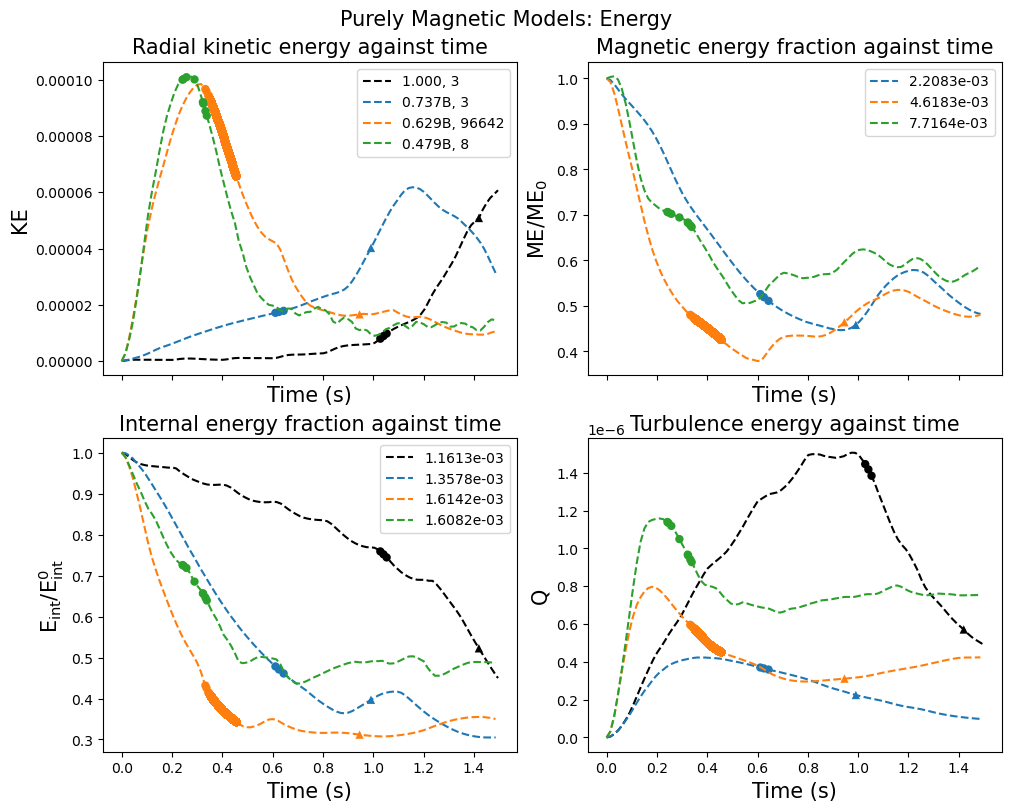

In [19]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, layout='constrained')
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_mass_CO = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []
final_mass_he = []

for i in magnetised:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    int_E = []
    turbE = []
    
    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T
        eps = f['epsilon'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        q = primitive[iturbq,1:-1,1,1:-1]/energycgs2code
        epsilon = eps[1:-1,1,1:-1]/energycgs2code
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        int_E.append(np.sum(dens*epsilon*vol))
        turbE.append(np.sum(dens*q*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True
        else:
            if t == n-1:
                table_time.append(0)

        
    star_masses = np.array(star_masses)
    unit = star_masses*clight**2
    KE = np.array(KE)/unit
    RKE = np.array(RKE)/unit
    ME = np.array(ME)/unit
    int_E = np.array(int_E)/unit
    turbE = np.array(turbE)/unit

    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    He_fraction = np.array(mass_dict['He'])/star_masses
    CO_fraction = (np.array(mass_dict['C'])+np.array(mass_dict['O']))/star_masses
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_CO.append(np.array(mass_dict['C']+mass_dict['O'])[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
    final_mass_he.append(np.array(mass_dict['He'])[-1]/solar)
    
    # Change variable to what you wanna plot
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_ME = np.interp(dett, times, ME)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_He = np.interp(dett, times, He_fraction)
    dett_y_CO = np.interp(dett, times, CO_fraction)
    dett_y_int_E = np.interp(dett, times, int_E)
    dett_y_turbE = np.interp(dett, times, turbE)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_ME = np.interp(escape_time, times, ME)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_He = np.interp(escape_time, times, He_fraction)
        escape_time_y_CO = np.interp(escape_time, times, CO_fraction)
        escape_time_y_int_E = np.interp(escape_time, times, int_E)
        escape_time_y_turbE = np.interp(escape_time, times, turbE)
    
    if i == 0:
        # Subplot 0,0
        axs[0,0].plot(times, KE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[0,0].scatter(dett, dett_y_KE, color='black', rasterized=True, edgecolors='none')
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, color='black', marker="^", rasterized=True, edgecolors='none')

        # Subplot 1,1
        axs[1,1].plot(times, turbE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[1,1].scatter(dett, dett_y_turbE, color='black', rasterized=True, edgecolors='none')
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_turbE, color='black', marker="^", rasterized=True, edgecolors='none')

        # Subplot 0,1
        axs[0,1].plot(times, ME/ME[0], linestyle='--', color='black')
        axs[0,1].scatter(dett, dett_y_ME/ME[0], color='black', rasterized=True, edgecolors='none')
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_ME/ME[0], color='black', marker="^", rasterized=True, edgecolors='none')

        # Subplot 1,0
        axs[1,0].plot(times, int_E/int_E[0], linestyle='--', color='black', label=f"{int_E[0]:.4e}")
        axs[1,0].scatter(dett, dett_y_int_E/int_E[0], color='black', rasterized=True, edgecolors='none')
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_int_E/int_E[0], color='black', marker="^", rasterized=True, edgecolors='none')
    else:
        # --- Subplot [0, 0] ---
        line_00, = axs[0,0].plot(times, KE, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        axs[0,0].scatter(dett, dett_y_KE, color=color_00, rasterized=True, edgecolors='none')
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, marker="^", color=color_00, rasterized=True, edgecolors='none')

        # --- Subplot [0, 1] ---
        line_01, = axs[1,1].plot(times, turbE, linestyle='--')
        color_01 = line_01.get_color()
        axs[1,1].scatter(dett, dett_y_turbE, color=color_01, rasterized=True, edgecolors='none')
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_turbE, marker="^", color=color_01, rasterized=True, edgecolors='none')

        # --- Subplot [1, 0] ---
        line_10, = axs[0,1].plot(times, ME/ME[0], linestyle='--', label=f"{(ME[0]):.4e}")
        color_10 = line_10.get_color()
        axs[0,1].scatter(dett, dett_y_ME/ME[0], color=color_10, rasterized=True, edgecolors='none')
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_ME/ME[0], marker="^", color=color_10, rasterized=True, edgecolors='none')

        # --- Subplot [1, 1] ---
        line_11, = axs[1,0].plot(times, int_E/int_E[0], linestyle='--', label=f"{int_E[0]:.4e}")
        color_11 = line_11.get_color()
        axs[1,0].scatter(dett, dett_y_int_E/int_E[0], color=color_11, rasterized=True, edgecolors='none')
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_int_E/int_E[0], marker="^", color=color_11, rasterized=True, edgecolors='none')


# --- Axes Labels & Titles Configuration ---
axs[0,0].set_ylabel(r'KE', fontsize=15)
axs[0,0].set_title("Radial kinetic energy against time", fontsize=15)
axs[0,0].set_xlabel(r'Time (s)', fontsize=15)
axs[0,0].legend()

axs[1,1].set_xlabel('Time (s)', fontsize=15)
axs[1,1].set_ylabel(r'Q', fontsize=15)
axs[1,1].set_title("Turbulence energy against time", fontsize=15)

axs[0,1].set_xlabel('Time (s)', fontsize=15)
axs[0,1].set_ylabel(r'ME/ME$_0$', fontsize=15)
axs[0,1].set_title("Magnetic energy fraction against time", fontsize=15)
axs[0,1].legend()

axs[1,0].set_xlabel('Time (s)', fontsize=15)
axs[1,0].set_ylabel(r'E$_\text{int}$/E${}^0_\text{int}$', fontsize=15)
axs[1,0].set_title("Internal energy fraction against time", fontsize=15)
axs[1,0].legend()

plt.suptitle('Purely Magnetic Models: Energy', fontsize=15)
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/m_e.pdf', bbox_inches='tight')

Matter escapes from the simulation domain


/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/1628982239.py:143: RuntimeWarning: invalid value encountered in divide
  axs[0,1].plot(times, RKE/RKE[0], linestyle='--', color='black')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/1628982239.py:144: RuntimeWarning: invalid value encountered in divide
  axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color='black')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/1628982239.py:146: RuntimeWarning: invalid value encountered in scalar divide
  axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], color='black', marker="^")
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/1628982239.py:149: RuntimeWarning: invalid value encountered in divide
  axs[1,0].plot(times, ME/ME[0], linestyle='--', color='black')
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_16298/1628982239.py:150: RuntimeWarning: invalid value encountered in divide
  axs[1,0].scatter(dett, dett_y_ME/ME[0

Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain


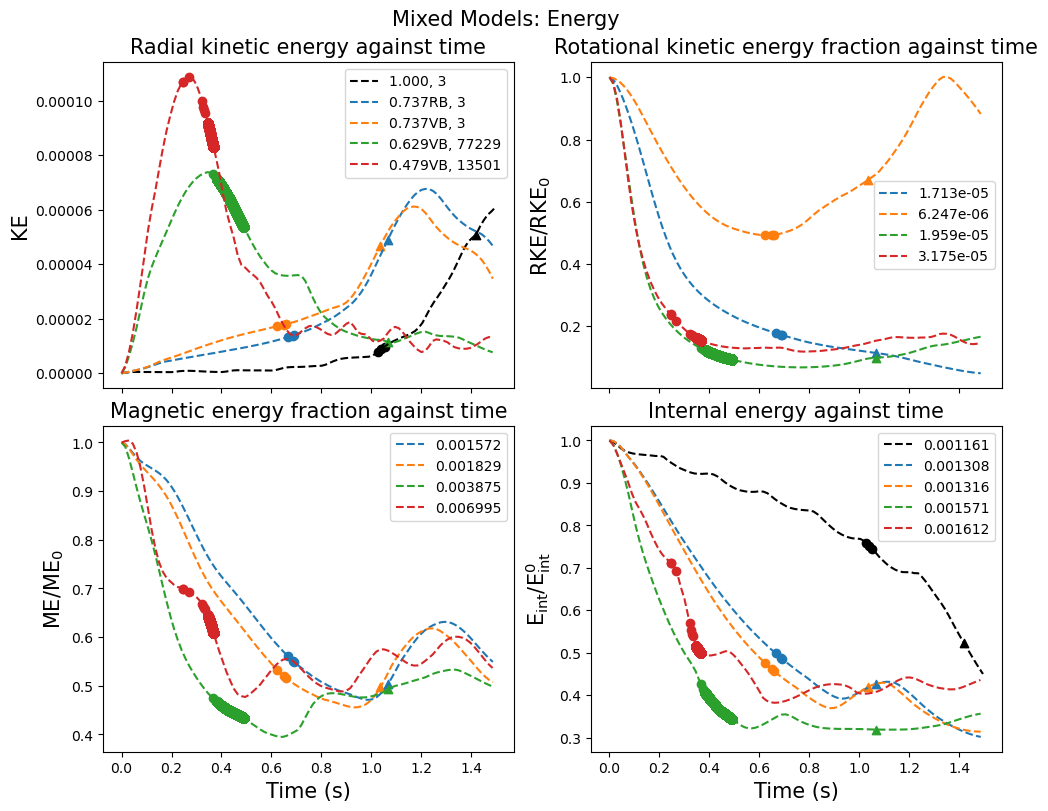

In [20]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, layout='constrained')
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_mass_CO = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []
final_mass_he = []

for i in mixed:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    int_E = []


    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T
        eps = f['epsilon'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        epsilon = eps[1:-1,1,1:-1]/energycgs2code
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        int_E.append(np.sum(dens*epsilon*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True
        else:
            if t == n-1:
                table_time.append(0)


    star_masses = np.array(star_masses)
    unit = star_masses*clight**2
    KE = np.array(KE)/unit
    RKE = np.array(RKE)/unit
    ME = np.array(ME)/unit
    int_E = np.array(int_E)/unit

    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    He_fraction = np.array(mass_dict['He'])/star_masses
    CO_fraction = (np.array(mass_dict['C'])+np.array(mass_dict['O']))/star_masses
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_CO.append(np.array(mass_dict['C']+mass_dict['O'])[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
    final_mass_he.append(np.array(mass_dict['He'])[-1]/solar)
    
    # Detonation interpolation maps
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_ME = np.interp(dett, times, ME)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_He = np.interp(dett, times, He_fraction)
    dett_y_CO = np.interp(dett, times, CO_fraction)
    dett_y_int_E = np.interp(dett, times, int_E)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_ME = np.interp(escape_time, times, ME)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_He = np.interp(escape_time, times, He_fraction)
        escape_time_y_CO = np.interp(escape_time, times, CO_fraction)
        escape_time_y_int_E = np.interp(escape_time, times, int_E)
    
    if i == 0:
        # Subplot 0,0
        axs[0,0].plot(times, KE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        axs[0,0].scatter(dett, dett_y_KE, color='black')
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, color='black', marker="^")

        # Subplot 0,1
        axs[0,1].plot(times, RKE/RKE[0], linestyle='--', color='black')
        axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color='black')
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], color='black', marker="^")

        # Subplot 1,0
        axs[1,0].plot(times, ME/ME[0], linestyle='--', color='black')
        axs[1,0].scatter(dett, dett_y_ME/ME[0], color='black')
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_ME/ME[0], color='black', marker="^")

        # Subplot 1,1
        axs[1,1].plot(times, int_E/int_E[0], linestyle='--', color='black', label=f"{int_E[0]:.4g}")
        axs[1,1].scatter(dett, dett_y_int_E/int_E[0], color='black')
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_int_E/int_E[0], color='black', marker="^")
        
    else:
        # --- Subplot [0, 0] ---
        line_00, = axs[0,0].plot(times, KE, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        axs[0,0].scatter(dett, dett_y_KE, color=color_00, rasterized=True)
        if escape:
            axs[0,0].scatter(escape_time, escape_time_y_KE, marker="^", color=color_00, rasterized=True)

        # --- Subplot [0, 1] ---
        line_01, = axs[0,1].plot(times, RKE/RKE[0], linestyle='--', label=f"{RKE[0]:.4g}")
        color_01 = line_01.get_color()
        axs[0,1].scatter(dett, dett_y_RKE/RKE[0], color=color_01, rasterized=True)
        if escape:
            axs[0,1].scatter(escape_time, escape_time_y_RKE/RKE[0], marker="^", color=color_01, rasterized=True)

        # --- Subplot [1, 0] ---
        line_10, = axs[1,0].plot(times, ME/ME[0], linestyle='--', label=f"{ME[0]:.4g}")
        color_10 = line_10.get_color()
        axs[1,0].scatter(dett, dett_y_ME/ME[0], color=color_10, rasterized=True)
        if escape:
            axs[1,0].scatter(escape_time, escape_time_y_ME/ME[0], marker="^", color=color_10, rasterized=True)

        # --- Subplot [1, 1] ---
        line_11, = axs[1,1].plot(times, int_E/int_E[0], linestyle='--', label=f"{int_E[0]:.4g}")
        color_11 = line_11.get_color()
        axs[1,1].scatter(dett, dett_y_int_E/int_E[0], color=color_11, rasterized=True)
        if escape:
            axs[1,1].scatter(escape_time, escape_time_y_int_E/int_E[0], marker="^", color=color_11, rasterized=True)


# --- Labels & Headings Configuration ---
axs[0,0].set_ylabel(r'KE', fontsize=15)
axs[0,0].set_title("Radial kinetic energy against time", fontsize=15)
axs[0,0].legend()

axs[0,1].set_ylabel(r'RKE/RKE$_0$', fontsize=15)
axs[0,1].set_title(r"Rotational kinetic energy fraction against time", fontsize=15)
axs[0,1].legend()

axs[1,0].set_xlabel('Time (s)', fontsize=15)
axs[1,0].set_ylabel(r'ME/ME$_0$', fontsize=15)
axs[1,0].set_title("Magnetic energy fraction against time", fontsize=15)
axs[1,0].legend()

axs[1,1].set_xlabel('Time (s)', fontsize=15)
axs[1,1].set_ylabel(r'E$_\text{int}$/E${}^0_\text{int}$', fontsize=15)
axs[1,1].set_title("Internal energy against time", fontsize=15)
axs[1,1].legend()

plt.suptitle('Mixed Models: Energy', fontsize=15)
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/mm_e.pdf', bbox_inches='tight')

Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain


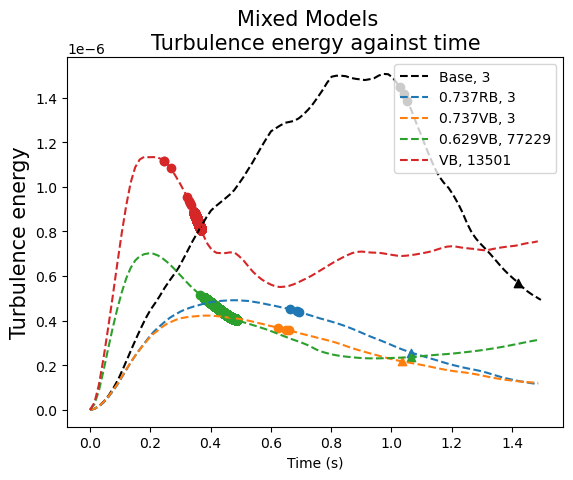

In [13]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []

for i in mixed:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    turbE = []
    
    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        q = primitive[iturbq, 1:-1,1,1:-1]/energycgs2code
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        turbE.append(np.sum(q*dens*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True

    star_masses = np.array(star_masses)
    unit = star_masses*clight**2
    KE = np.array(KE)/unit
    RKE = np.array(RKE)/unit
    ME = np.array(ME)/unit
    turbE = np.array(turbE)/unit

    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    CO_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
    
    # Detonation interpolation maps
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_turbE = np.interp(dett, times, turbE)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_turbE = np.interp(escape_time, times, turbE)

    if i == 0:
        plt.plot(times, turbE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        plt.scatter(dett, dett_y_turbE, color='black', rasterized=True)
        if escape:
            plt.scatter(escape_time, escape_time_y_turbE, color='black', marker="^", rasterized=True)
    else:
        # --- Subplot [0, 0] ---
        line_00, = plt.plot(times, turbE, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        plt.scatter(dett, dett_y_turbE, color=color_00, rasterized=True)
        if escape:
            plt.scatter(escape_time, escape_time_y_turbE, marker="^", color=color_00, rasterized=True)


# --- Labels and Figure Configuration ---
plt.ylabel(r'Turbulence energy', fontsize=15)
plt.xlabel(r"Time (s)")
plt.title("Turbulence energy against time", fontsize=15)
plt.legend()

plt.suptitle('Mixed Models', fontsize=15)
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/CUHKthesis/figures/m_turb.pdf', bbox_inches='tight')

Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain
Matter escapes from the simulation domain


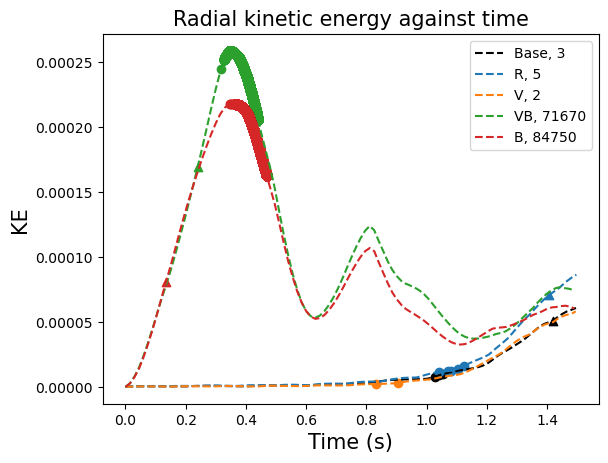

In [126]:
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []

for i in [0,1,9,10,11]:

    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    working_directory = data_path+"/outfile"
    files = []
    for f in glob(working_directory+'/*.hdf5'):
        files.append(f)
    n = len(files)-1

    star_masses = []
    mass_dict = {}
    times = []
    KE = []
    RKE = []
    ME = []
    turbE = []
    
    for j in range(ini56-ihe4+1):
        mass_dict[ion_names[j]] = []
        
    escape = False
    for t in range(n):
        filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
        f = h5py.File(filename, "r")
        
        if t == 0:
            vol = f["vol"][:].T
            vol = vol[:,0,:]/(lencgs2code**3)
            atmosphere = f['prim_a'][:].T
            atmo_rho = atmosphere[0]/rhocgs2code
        
        primitive = f['primitive'][:].T

        dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
        vx = primitive[ivx,1:-1,1,1:-1]*clight
        vy = primitive[ivy,1:-1,1,1:-1]*clight
        vz = primitive[ivz,1:-1,1,1:-1]*clight
        q = primitive[iturbq, 1:-1,1,1:-1]/energycgs2code
        time = f['time'][0]/tcgs2code

        bcells = f['bcell'][:].T
        bx = bcells[0,1:,1,1:]/gauss2code
        by = bcells[1,1:,1,1:]/gauss2code
        bz = bcells[2,1:,1,1:]/gauss2code

        dens[dens<= atmo_rho] = 0.0

        if t == 0:
            initial = np.sum(dens*vol)

        star_masses.append(np.sum(dens*vol))
        for j in range(ini56-ihe4+1):
            tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
            mass_dict[ion_names[j]].append(tmp)

        KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
        RKE.append(0.5*np.sum(dens*vol*vy**2))
        ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
        turbE.append(np.sum(q*dens*vol))
        times.append(f['time'][0]/tcgs2code)

        if t == n-1:
            dett = f['detonations'][:]/tcgs2code

        if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
            if escape == False:
                print("Matter escapes from the simulation domain")
                escape_time = times[-1]
                table_time.append(times[-1])
                escape = True

    star_masses = np.array(star_masses)
    unit = star_masses*clight**2
    KE = np.array(KE)/unit
    RKE = np.array(RKE)/unit
    ME = np.array(ME)/unit
    turbE = np.array(turbE)/unit

    IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
    Ni_fraction = np.array(mass_dict['Ni'])/star_masses
    CO_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))
    times = np.array(times)

    mass_in_domain.append(star_masses[-1]/solar)
    final_KE.append( KE[-1] )
    final_RKE.append(RKE[-1] )
    final_ME.append(ME[-1])
    final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
    final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
    
    # Detonation interpolation maps
    dett_y_KE = np.interp(dett, times, KE)
    dett_y_RKE = np.interp(dett, times, RKE)
    dett_y_Ni = np.interp(dett, times, Ni_fraction)
    dett_y_IME = np.interp(dett, times, IME_fraction)
    dett_y_turbE = np.interp(dett, times, turbE)

    # --- Conditional Escape Interpolation ---
    if escape:
        escape_time_y_KE = np.interp(escape_time, times, KE)
        escape_time_y_RKE = np.interp(escape_time, times, RKE)
        escape_time_y_Ni = np.interp(escape_time, times, Ni_fraction)
        escape_time_y_IME = np.interp(escape_time, times, IME_fraction)
        escape_time_y_turbE = np.interp(escape_time, times, turbE)

    if i == 0:
        plt.plot(times, KE, linestyle='--', color='black', label=names[i]+', '+str(len(dett)))
        plt.scatter(dett, dett_y_KE, color='black', rasterized=True)
        if escape:
            plt.scatter(escape_time, escape_time_y_KE, color='black', marker="^", rasterized=True)
    else:
        # --- Subplot [0, 0] ---
        line_00, = plt.plot(times, KE, linestyle='--', label=names[i]+', '+str(len(dett)))
        color_00 = line_00.get_color()
        plt.scatter(dett, dett_y_KE, color=color_00, rasterized=True)
        if escape:
            plt.scatter(escape_time, escape_time_y_KE, marker="^", color=color_00, rasterized=True)


# --- Labels and Figure Configuration ---
plt.ylabel(r'KE', fontsize=15)
plt.xlabel(r"Time (s)", fontsize=15)
plt.title("Radial kinetic energy against time", fontsize=15)
plt.legend()

# plt.suptitle('Mixed Models', fontsize=15)
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/RKE.pdf', bbox_inches='tight',transparent=True)

Matter escapes from the simulation domain in 1.000 
Matter escapes from the simulation domain in 0.479VB low_suppression
Matter escapes from the simulation domain in 0.479B no_suppression


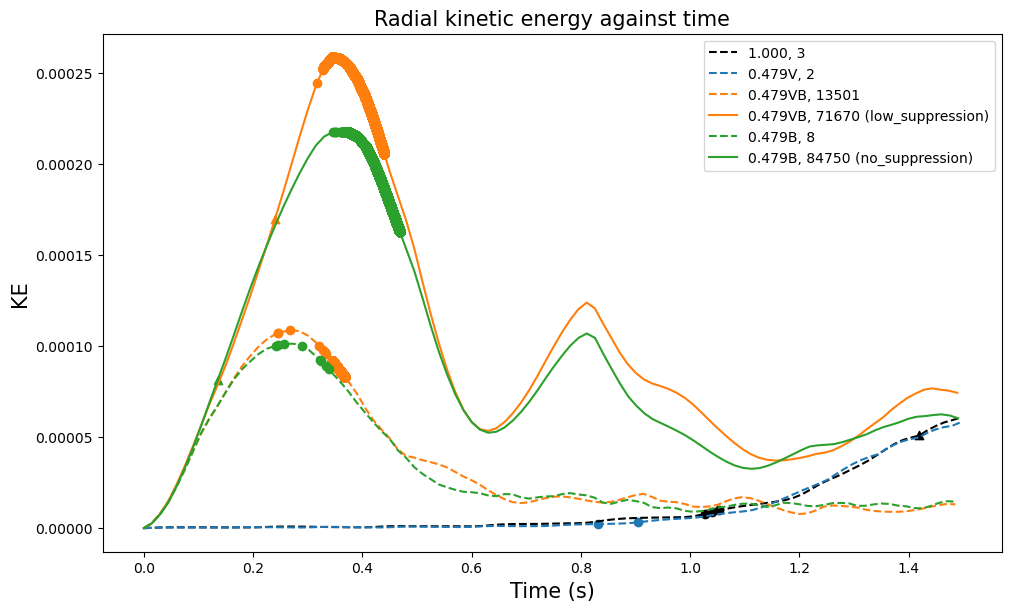

In [ ]:
# ... (assume your other setup code and variables like data_paths, names, etc. are loaded) ...
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')

mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_mass_CO = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []
final_mass_he = []

# --- SPECIFY YOUR SUBDIRECTORIES HERE ---
subdir_mapping = {
    0: "",
    9: "",
    10: "low_suppression",
    11: "no_suppression"
}

for i in [0, 9, 10, 11]:

    data_path = data_paths[i]     
    
    # Read profile once per 'i'
    profile_dir = data_path + '/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(profile_dir)

    # Fetch the specific subdirectory for this 'i'
    target_subdir = subdir_mapping.get(i, "")
    
    # Determine the loop list: main directory first (""), then the subdirectory if it exists
    dirs_to_run = ["", target_subdir] if target_subdir != "" else [""]

    # Loop over main directory and the dynamically fetched subdirectory
    for is_subdir, subdir in enumerate(dirs_to_run):
        
        # Configure paths, labels, and linestyles for this pass
        if subdir == "":
            working_directory = data_path + "/outfile"
            label_suffix = ""
            ls = '--'   
        else:
            working_directory = os.path.join(data_path, "outfile", subdir)
            label_suffix = f" ({subdir})"
            ls = '-' 

        files = []
        for f in glob(working_directory + '/*.hdf5'):
            files.append(f)
            
        # --- NEW SAFETY CHECK ---
        if len(files) == 0:
            print(f"⚠️ WARNING: No .hdf5 files found in '{working_directory}'. Skipping this directory.")
            continue  
        # ------------------------
        
        n = len(files) - 1

        star_masses = []
        mass_dict = {}
        times = []
        KE = []
        RKE = []
        ME = []
        int_E = []

        for j in range(ini56-ihe4+1):
            mass_dict[ion_names[j]] = []
            
        escape = False
        
        for t in range(n):
            filename = working_directory + "/rkiter-" + str(t) + "-nm.hdf5"
            
            f = h5py.File(filename, "r")
            
            if t == 0:
                vol = f["vol"][:].T
                vol = vol[:,0,:]/(lencgs2code**3)
                atmosphere = f['prim_a'][:].T
                atmo_rho = atmosphere[0]/rhocgs2code
            
            primitive = f['primitive'][:].T
            eps = f['epsilon'][:].T

            dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
            vx = primitive[ivx,1:-1,1,1:-1]*clight
            vy = primitive[ivy,1:-1,1,1:-1]*clight
            vz = primitive[ivz,1:-1,1,1:-1]*clight
            epsilon = eps[1:-1,1,1:-1]/energycgs2code
            time = f['time'][0]/tcgs2code

            bcells = f['bcell'][:].T
            bx = bcells[0,1:,1,1:]/gauss2code
            by = bcells[1,1:,1,1:]/gauss2code
            bz = bcells[2,1:,1,1:]/gauss2code

            dens[dens<= atmo_rho] = 0.0

            if t == 0:
                initial = np.sum(dens*vol)

            star_masses.append(np.sum(dens*vol))
            for j in range(ini56-ihe4+1):
                tmp = np.sum(dens*primitive[j+ihe4,1:-1,1,1:-1]*vol)
                mass_dict[ion_names[j]].append(tmp)

            KE.append(0.5*np.sum(dens*vol*(vx**2+vz**2)))
            RKE.append(0.5*np.sum(dens*vol*vy**2))
            ME.append(0.5*np.sum((bx**2+by**2+bz**2)*vol))
            int_E.append(np.sum(dens*epsilon*vol))
            times.append(f['time'][0]/tcgs2code)

            if t == n-1:
                dett = f['detonations'][:]/tcgs2code

            if np.any(dens[:,0]!=0) or np.any(dens[:,-1]!=0) or np.any(dens[-1,:]!=0):
                if escape == False:
                    print(f"Matter escapes from the simulation domain in {names[i]} {subdir}")
                    escape_time = times[-1]
                    table_time.append(times[-1])
                    escape = True
            else:
                if t == n-1:
                    table_time.append(0)

        star_masses = np.array(star_masses)
        unit = star_masses * clight**2
        KE = np.array(KE) / unit
        RKE = np.array(RKE) / unit
        ME = np.array(ME) / unit
        int_E = np.array(int_E) / unit

        IME_fraction = (np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))/star_masses
        Ni_fraction = np.array(mass_dict['Ni'])/star_masses
        He_fraction = np.array(mass_dict['He'])/star_masses
        CO_fraction = (np.array(mass_dict['C'])+np.array(mass_dict['O']))/star_masses
        times = np.array(times)

        mass_in_domain.append(star_masses[-1]/solar)
        final_KE.append( KE[-1] )
        final_RKE.append(RKE[-1] )
        final_ME.append(ME[-1])
        final_mass_ni.append(np.array(mass_dict['Ni'])[-1]/solar)
        # Fixed list concatenation logic below based on your original snippet
        final_mass_CO.append((np.array(mass_dict['C']) + np.array(mass_dict['O']))[-1]/solar) 
        final_mass_ime.append((np.array(mass_dict['Ne'])+np.array(mass_dict['Mg'])+np.array(mass_dict['Si']))[-1]/solar)
        final_mass_he.append(np.array(mass_dict['He'])[-1]/solar)
        
        # Detonation interpolation maps
        dett_y_KE = np.interp(dett, times, KE)

        # --- Conditional Escape Interpolation ---
        if escape:
            escape_time_y_KE = np.interp(escape_time, times, KE)
        
        current_label = f"{names[i]}, {len(dett)}{label_suffix}"

        # --- Plotting Logic (Mapped to single 'ax') ---
        if i == 0:
            color = 'black'
            ax.plot(times, KE, linestyle=ls, color=color, label=current_label)
        else:
            if is_subdir == 0:
                # Main run: Plot and capture the auto-assigned color
                line, = ax.plot(times, KE, linestyle=ls, label=current_label)
                color = line.get_color()
            else:
                # Subdir run: Force the line to match the color of the main run for this 'i'
                ax.plot(times, KE, linestyle=ls, color=color, label=current_label)

        # Scatter points (Applied to both main and subdir curves)
        ax.scatter(dett, dett_y_KE, color=color, rasterized=True)
        if escape:
            ax.scatter(escape_time, escape_time_y_KE, marker="^", color=color, rasterized=True)

# --- Labels & Headings Configuration ---
ax.set_xlabel('Time (s)', fontsize=15)
ax.set_ylabel('KE', fontsize=15)
ax.set_title("Radial kinetic energy against time", fontsize=15)
ax.legend()

plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/KE.pdf', bbox_inches='tight', transparent=True)

In [10]:
names

['1.000',
 '0.737R',
 '0.737V',
 '0.737RB',
 '0.737VB',
 '0.737B',
 '0.629V',
 '0.629VB',
 '0.629B',
 '0.479V',
 '0.479VB',
 '0.479B']

Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.629_Bs_6.997E+12_rotat_4.608E-01_mass_1.985/outfile
Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.629_Bs_8.446E+12_rotat_0.000E+00_mass_2.037/outfile
Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.479_Bs_1.300E+13_rotat_1.137E+00_mass_2.787/outfile
Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.479_Bs_1.431E+13_rotat_0.000E+00_mass_2.863/outfile


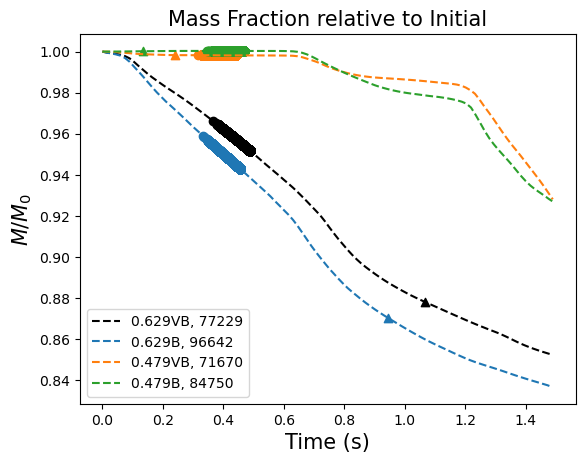

In [21]:
# --- Storage Lists ---
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
mass_in_domain = []
nve_mass = [] 
final_mass_ni = []
final_mass_ime = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []

# Tracker to handle the custom styling/color for the very first line plotted
plot_counter = 0

for i in [7,8,10,11]:

    data_path = data_paths[i]     
    profile_directory = os.path.join(data_path, 'profile')
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(profile_directory)
    
    # Define potential data paths inside the outfile directory
    base_outfile_dir = os.path.join(data_path, "outfile")
    
    # Automatically scan and identify directories containing simulation outputs
    target_variants = []
    
    # 1. Check the standard outfile directory
    if glob(os.path.join(base_outfile_dir, '*.hdf5')):
        target_variants.append((base_outfile_dir, ""))
        
    if i == 10:
        # 2. Check the low_suppression subdirectory
        low_supp_dir = os.path.join(base_outfile_dir, "low_suppression")
        if os.path.exists(low_supp_dir) and glob(os.path.join(low_supp_dir, '*.hdf5')):
            target_variants.append((low_supp_dir, " (Lower C)"))

    # 2. Check the no_suppression subdirectory
    low_supp_dir = os.path.join(base_outfile_dir, "no_suppression")
    if os.path.exists(low_supp_dir) and glob(os.path.join(low_supp_dir, '*.hdf5')):
        target_variants.append((low_supp_dir, " (C=0)"))
        
    # Fallback to prevent downstream crashes if no files are found matching the pattern
    if not target_variants:
        target_variants.append((base_outfile_dir, ""))

    # --- Process Each Available Data Variant ---
    for working_directory, label_suffix in target_variants:
        
        files = glob(os.path.join(working_directory, '*.hdf5'))
        n = len(files) - 1

        star_masses = []
        mass_dict = {}
        times = []
        KE = []
        RKE = []
        ME = []
        turbE = []
        nve_KE = []

        for j in range(ini56 - ihe4 + 1):
            mass_dict[ion_names[j]] = []
            
        escape = False
        for t in range(n):
            # Generalized filename resolution
            filename = os.path.join(working_directory, f"rkiter-{t}-nm.hdf5")
            f = h5py.File(filename, "r")
            
            if t == 0:
                vol = f["vol"][:].T
                vol = vol[:, 0, :] / (lencgs2code**3)
                atmosphere = f['prim_a'][:].T
                atmo_rho = atmosphere[0] / rhocgs2code
            
            primitive = f['primitive'][:].T

            dens = primitive[irho, 1:-1, 1, 1:-1] / rhocgs2code
            vx = primitive[ivx, 1:-1, 1, 1:-1] * clight
            vy = primitive[ivy, 1:-1, 1, 1:-1] * clight
            vz = primitive[ivz, 1:-1, 1, 1:-1] * clight
            q = primitive[iturbq, 1:-1, 1, 1:-1] / energycgs2code
            time = f['time'][0] / tcgs2code

            bcells = f['bcell'][:].T
            bx = bcells[0, 1:, 1, 1:] / gauss2code
            by = bcells[1, 1:, 1, 1:] / gauss2code
            bz = bcells[2, 1:, 1, 1:] / gauss2code

            dens[dens <= atmo_rho] = 0.0

            if t == 0:
                initial = np.sum(dens * vol)

            star_masses.append(np.sum(dens * vol))
            for j in range(ini56 - ihe4 + 1):
                tmp = np.sum(dens * primitive[j + ihe4, 1:-1, 1, 1:-1] * vol)
                mass_dict[ion_names[j]].append(tmp)

            KE.append(0.5 * np.sum(dens * vol * (vx**2 + vz**2)))
            RKE.append(0.5 * np.sum(dens * vol * vy**2))
            ME.append(0.5 * np.sum((bx**2 + by**2 + bz**2) * vol))
            turbE.append(np.sum(q * dens * vol))
            times.append(f['time'][0] / tcgs2code)
            nve_mass.append(np.sum((dens * vol)[vx<0]))
            nve_KE.append(np.sum((dens * vol * (vx**2 + vz**2))[vx<0]))

            if t == n - 1:
                dett = f['detonations'][:] / tcgs2code

            if np.any(dens[:, 0] != 0) or np.any(dens[:, -1] != 0) or np.any(dens[-1, :] != 0):
                if not escape:
                    print(f"Matter escapes from simulation domain: {working_directory}")
                    escape_time = times[-1]
                    table_time.append(times[-1])
                    escape = True
            f.close()

        KE = np.array(KE)
        RKE = np.array(RKE)
        ME = np.array(ME)
        turbE = np.array(turbE)
        star_masses = np.array(star_masses)
        IME_fraction = (np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si'])) / star_masses
        Ni_fraction = np.array(mass_dict['Ni']) / star_masses
        CO_fraction = (np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si']))
        times = np.array(times)

        mass_in_domain.append(star_masses[-1] / solar)
        final_KE.append(KE[-1])
        final_RKE.append(RKE[-1])
        final_ME.append(ME[-1])
        final_mass_ni.append(np.array(mass_dict['Ni'])[-1] / solar)
        final_mass_ime.append((np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si']))[-1] / solar)
        
        # Detonation interpolation map
        dett_y = np.interp(dett, times, star_masses / initial)

        # Conditional Escape Interpolation
        if escape:
            escape_time_y = np.interp(escape_time, times, star_masses / initial)
        
        # Generate generalized label combining dataset name and folder context
        plot_label = f"{names[i]}{label_suffix}, {len(dett)}"
        
        # --- Multi-Variant Plotting Logic ---
        if plot_counter == 0:
            plt.plot(times, star_masses / initial, linestyle='--', color='black', label=plot_label)
            plt.scatter(dett, dett_y, color='black', rasterized=True)
            if escape:
                plt.scatter(escape_time, escape_time_y, color='black', marker="^", rasterized=True)
        else:
            line_v, = plt.plot(times, star_masses / initial, linestyle='--', label=plot_label)
            color_v = line_v.get_color()
            plt.scatter(dett, dett_y, color=color_v, rasterized=True)
            if escape:
                plt.scatter(escape_time, escape_time_y, marker="^", color=color_v, rasterized=True)
                
        plot_counter += 1

# --- Labels and Figure Configuration ---
plt.xlabel(r"Time (s)", fontsize=15)
plt.ylabel(r"$M$/$M_0$", fontsize=15)
plt.title("Mass Fraction relative to Initial", fontsize=15)
plt.legend()
plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/mc_r.pdf', bbox_inches='tight', transparent=True)

Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.629_Bs_6.997E+12_rotat_4.608E-01_mass_1.985/outfile


/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_13421/4285632358.py:140: RuntimeWarning: invalid value encountered in divide
  dett_y = np.interp(dett, times, nve_KE/KE)
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_13421/4285632358.py:144: RuntimeWarning: invalid value encountered in divide
  escape_time_y = np.interp(escape_time, times, nve_KE/KE)
/var/folders/8x/zqxvmnw13vqc4kp8gflj4lcw0000gn/T/ipykernel_13421/4285632358.py:156: RuntimeWarning: invalid value encountered in divide
  line_v, = plt.plot(times, nve_KE/KE, linestyle='--', label=plot_label)


Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.629_Bs_8.446E+12_rotat_0.000E+00_mass_2.037/outfile
Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.479_Bs_1.300E+13_rotat_1.137E+00_mass_2.787/outfile
Matter escapes from simulation domain: /Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_runs/Output_CentralDensity_9.477_AxisRatio_0.479_Bs_1.431E+13_rotat_0.000E+00_mass_2.863/outfile


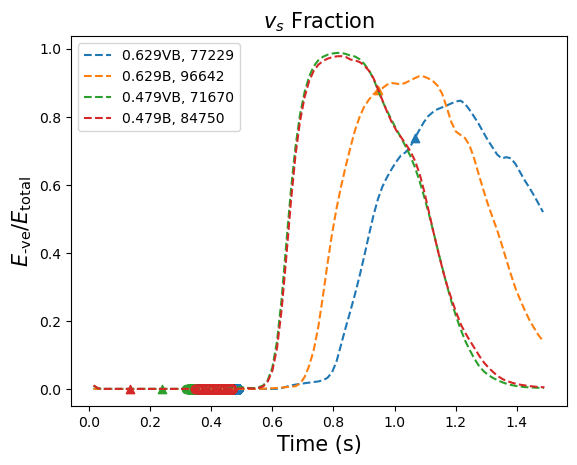

In [27]:
# --- Storage Lists ---
ion_names = ["He", "C", "O", "Ne", "Mg", "Si", "Ni"]
mass_in_domain = []
final_mass_ni = []
final_mass_ime = []
final_KE = []
final_RKE = []
final_ME = []
table_time = []

# Tracker to handle the custom styling/color for the very first line plotted
plot_counter = 1

for i in [7,8,10,11]:

    data_path = data_paths[i]     
    profile_directory = os.path.join(data_path, 'profile')
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(profile_directory)
    
    # Define potential data paths inside the outfile directory
    base_outfile_dir = os.path.join(data_path, "outfile")
    
    # Automatically scan and identify directories containing simulation outputs
    target_variants = []
    
    # 1. Check the standard outfile directory
    if glob(os.path.join(base_outfile_dir, '*.hdf5')):
        target_variants.append((base_outfile_dir, ""))
        
    if i == 10:
        # 2. Check the low_suppression subdirectory
        low_supp_dir = os.path.join(base_outfile_dir, "low_suppression")
        if os.path.exists(low_supp_dir) and glob(os.path.join(low_supp_dir, '*.hdf5')):
            target_variants.append((low_supp_dir, " (Lower C)"))

    # 2. Check the no_suppression subdirectory
    low_supp_dir = os.path.join(base_outfile_dir, "no_suppression")
    if os.path.exists(low_supp_dir) and glob(os.path.join(low_supp_dir, '*.hdf5')):
        target_variants.append((low_supp_dir, " (C=0)"))
        
    # Fallback to prevent downstream crashes if no files are found matching the pattern
    if not target_variants:
        target_variants.append((base_outfile_dir, ""))

    # --- Process Each Available Data Variant ---
    for working_directory, label_suffix in target_variants:
        
        files = glob(os.path.join(working_directory, '*.hdf5'))
        n = len(files) - 1

        star_masses = []
        nve_mass = [] 
        nve_KE = []
        mass_dict = {}
        times = []
        KE = []
        RKE = []
        ME = []
        turbE = []
        
        for j in range(ini56 - ihe4 + 1):
            mass_dict[ion_names[j]] = []
            
        escape = False
        for t in range(n):
            # Generalized filename resolution
            filename = os.path.join(working_directory, f"rkiter-{t}-nm.hdf5")
            f = h5py.File(filename, "r")
            
            if t == 0:
                vol = f["vol"][:].T
                vol = vol[:, 0, :] / (lencgs2code**3)
                atmosphere = f['prim_a'][:].T
                atmo_rho = atmosphere[0] / rhocgs2code
            
            primitive = f['primitive'][:].T

            dens = primitive[irho, 1:-1, 1, 1:-1] / rhocgs2code
            vx = primitive[ivx, 1:-1, 1, 1:-1] * clight
            vy = primitive[ivy, 1:-1, 1, 1:-1] * clight
            vz = primitive[ivz, 1:-1, 1, 1:-1] * clight
            q = primitive[iturbq, 1:-1, 1, 1:-1] / energycgs2code
            time = f['time'][0] / tcgs2code

            bcells = f['bcell'][:].T
            bx = bcells[0, 1:, 1, 1:] / gauss2code
            by = bcells[1, 1:, 1, 1:] / gauss2code
            bz = bcells[2, 1:, 1, 1:] / gauss2code

            dens[dens <= atmo_rho] = 0.0

            if t == 0:
                initial = np.sum(dens * vol)

            star_masses.append(np.sum(dens * vol))
            nve_mass.append(np.sum((dens * vol)[vx<0]))

            for j in range(ini56 - ihe4 + 1):
                tmp = np.sum(dens * primitive[j + ihe4, 1:-1, 1, 1:-1] * vol)
                mass_dict[ion_names[j]].append(tmp)

            KE.append(0.5 * np.sum(dens * vol * (vx**2)))
            nve_KE.append(0.5 * np.sum((dens * vol * (vx**2))[vx<0]))
            RKE.append(0.5 * np.sum(dens * vol * vy**2))
            ME.append(0.5 * np.sum((bx**2 + by**2 + bz**2) * vol))
            turbE.append(np.sum(q * dens * vol))
            times.append(f['time'][0] / tcgs2code)
            

            if t == n - 1:
                dett = f['detonations'][:] / tcgs2code

            if np.any(dens[:, 0] != 0) or np.any(dens[:, -1] != 0) or np.any(dens[-1, :] != 0):
                if not escape:
                    print(f"Matter escapes from simulation domain: {working_directory}")
                    escape_time = times[-1]
                    table_time.append(times[-1])
                    escape = True
            f.close()

        KE = np.array(KE)
        RKE = np.array(RKE)
        ME = np.array(ME)
        turbE = np.array(turbE)
        star_masses = np.array(star_masses)
        IME_fraction = (np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si'])) / star_masses
        Ni_fraction = np.array(mass_dict['Ni']) / star_masses
        CO_fraction = (np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si']))
        times = np.array(times)
        nve_mass_fraction = np.array(nve_mass)/star_masses

        mass_in_domain.append(star_masses[-1] / solar)
        final_KE.append(KE[-1])
        final_RKE.append(RKE[-1])
        final_ME.append(ME[-1])
        final_mass_ni.append(np.array(mass_dict['Ni'])[-1] / solar)
        final_mass_ime.append((np.array(mass_dict['Ne']) + np.array(mass_dict['Mg']) + np.array(mass_dict['Si']))[-1] / solar)
        
        # Detonation interpolation map
        dett_y = np.interp(dett, times, nve_KE/KE)

        # Conditional Escape Interpolation
        if escape:
            escape_time_y = np.interp(escape_time, times, nve_KE/KE)
        
        # Generate generalized label combining dataset name and folder context
        plot_label = f"{names[i]}{label_suffix}, {len(dett)}"
        
        # --- Multi-Variant Plotting Logic ---
        if plot_counter == 0:
            plt.plot(times, nve_KE/KE, linestyle='--', color='black', label=plot_label)
            plt.scatter(dett, dett_y, color='black', rasterized=True)
            if escape:
                plt.scatter(escape_time, escape_time_y, color='black', marker="^", rasterized=True)
        else:
            line_v, = plt.plot(times, nve_KE/KE, linestyle='--', label=plot_label)
            color_v = line_v.get_color()
            plt.scatter(dett, dett_y, color=color_v, rasterized=True)
            if escape:
                plt.scatter(escape_time, escape_time_y, marker="^", color=color_v, rasterized=True)
                
        plot_counter += 1

# --- Labels and Figure Configuration ---
plt.xlabel(r"Time (s)", fontsize=15)
plt.ylabel(r"$E_\text{-ve}$/$E_\text{total}$", fontsize=15)
plt.title(r"$v_s$ Fraction", fontsize=15)
plt.legend()
# plt.savefig('/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/mc_r.pdf', bbox_inches='tight', transparent=True)

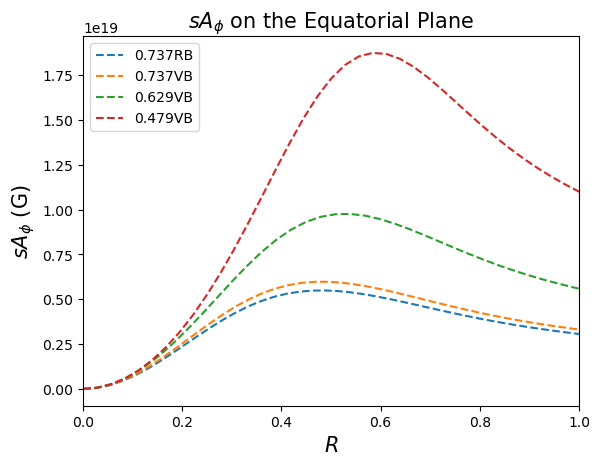

In [72]:
for i in mixed:
    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, Aphi, vphi = read_star(working_directory)
    
    if i == 0:
        continue
    else:  
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)]/clight, linestyle='--',label=names[i])
    
plt.xlabel(r'$R$', fontsize=15)
plt.ylabel(r'$s A_\phi$ (G)', fontsize=15)
plt.xlim(left=0,right=1.0)
plt.title(r"$s A_\phi$ on the Equatorial Plane", fontsize=15)
plt.legend()
# plt.savefig("/mnt3/cnchong/thesis_runs/plots/vphi_rM.pdf", bbox_inches="tight")

In [ ]:
for i in mm:
    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    # filename = data_path+"/outfile/rkiter-"+str(0)+"-nm.hdf5"
    # f = h5py.File(filename, "r")
    # primitive = f['primitive'][:].T
    # rho = primitive[0,1:-1,1,1:-1]/rhocgs2code
    
    if i == 0:
        plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='black')
    else:  
        plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i])
    
plt.xlabel(r'$R$', fontsize=15)
plt.ylabel(r'$\rho$ (gcm$^{-3}$)', fontsize=15)
plt.xlim(left=0,right=1.0)
plt.title(r"$\rho$ on the Equatorial Plane", fontsize=15)
plt.legend()
plt.savefig("/mnt3/cnchong/thesis_runs/plots/rho_rMB.pdf", bbox_inches="tight")


In [ ]:
for i in mm:
    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, Aphi, vphi = read_star(working_directory)
    
    # filename = data_path+"/outfile/rkiter-"+str(0)+"-nm.hdf5"
    # f = h5py.File(filename, "r")
    # primitive = f['primitive'][:].T
    # rho = primitive[0,1:-1,1,1:-1]/rhocgs2code
    
    if i == 3:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='magenta')
    if i == 4:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='violet')
    if i == 5:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='mediumpurple')
    if i == 7:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='firebrick')
    if i == 8:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='red')
    if i == 10:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='gold')
    if i == 11:
        plt.plot(x1f/1e5/req[i],(x1f*Aphi).T[:,int(Aphi.shape[0]/2)], linestyle='--',label=names[i],color='green')
    
plt.xlabel(r'$R$', fontsize=15)
plt.ylabel(r'$s A_\phi$ (Gcm$^{2}$)', fontsize=15)
plt.xlim(left=0,right=1.0)
plt.title(r"$s A_\phi$ on the Equatorial Plane", fontsize=15)
plt.legend()
plt.savefig("/mnt3/cnchong/thesis_runs/plots/Aphi_r.pdf", bbox_inches="tight")

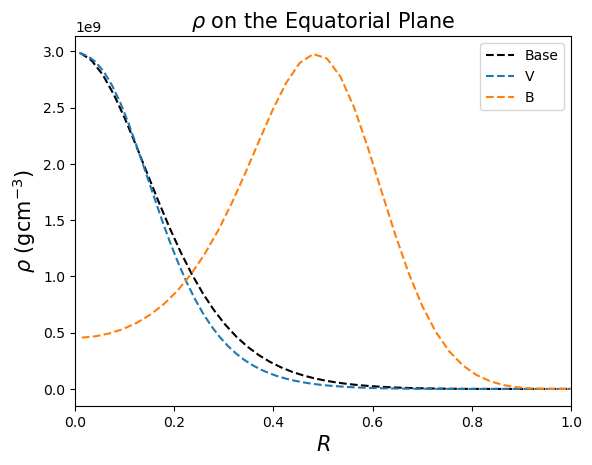

In [135]:
for i in [0,9,11]:
    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    
    # filename = data_path+"/outfile/rkiter-"+str(0)+"-nm.hdf5"
    # f = h5py.File(filename, "r")
    # primitive = f['primitive'][:].T
    # rho = primitive[0,1:-1,1,1:-1]/rhocgs2code

    if i == 0:
        plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), color="black", linestyle='--',label=names[i])
    else:
        plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i])

    # if i == 3:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='magenta')
    # if i == 4:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='violet')
    # if i == 5:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='mediumpurple')
    # if i == 7:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='firebrick')
    # if i == 8:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='red')
    # if i == 10:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='gold')
    # if i == 11:
    #     plt.plot(x1c/1e5/req[i],(rho.T[:,int(rho.shape[0]/2)]), linestyle='--',label=names[i],color='green')
    
plt.xlabel(r'$R$', fontsize=15)
plt.ylabel(r'$\rho$ (gcm$^{-3}$)', fontsize=15)
plt.xlim(left=0,right=1.0)
plt.title(r"$\rho$ on the Equatorial Plane", fontsize=15)
plt.legend()
# plt.savefig("/mnt3/cnchong/thesis_runs/plots/rho_rMB.pdf", bbox_inches="tight")
plt.savefig("/Users/cnchong/Uni stuff/MPhil/Thesis Stuff/thesis_presentation/rho_rMB.pdf", transparent = True)

In [ ]:
for i in magnetised:
    data_path = data_paths[i]     
    working_directory = data_path+'/profile'
    x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
    filename = data_path+"/outfile/rkiter-"+str(0)+"-nm.hdf5"
    f = h5py.File(filename, "r")
    bcells = f['bcell'][:].T
    bx = bcells[0,1:,1,1:]/gauss2code
    bz = bcells[2,1:,1,1:]/gauss2code
    f.close()
    
    if i == 0:
        continue
    else:  
        plt.plot(x1c/1e5/req[i], 0.5*np.log(bx**2+bz**2)[:,int(bx.shape[1]/2)], linestyle='--',label=names[i])
    
plt.xlabel(r'$R$', fontsize=15)
plt.ylabel(r'$\log |B|$ (G)', fontsize=15)
# plt.xlim(left=0,right=1.0)
plt.title(r"$\log |B|$ on the Equatorial Plane", fontsize=15)
plt.legend()
# plt.savefig("/mnt3/cnchong/thesis_runs/plots/B_rB.pdf", bbox_inches="tight")

In [73]:
data_path = data_paths[0]
filename = data_path+"/outfile/rkiter-"+str(0)+"-nm.hdf5"
f = h5py.File(filename, "r")
vol = f["vol"][:].T
vol = vol[:,0,:]
atmosphere = f['prim_a'][:].T
atmo_rho = atmosphere[0]

primitive = f['primitive'][:].T
rho = primitive[irho,1:-1,1,1:-1]
v2 =  primitive[ivy,1:-1,1,1:-1]

p = primitive[itau,1:-1,1,1:-1]
bcells = f['bcell'][:].T
bx = bcells[0,1:,1,1:]
by = bcells[1,1:,1,1:]
bz = bcells[2,1:,1,1:]

scaG1 = primitive[iscaG1, 1:-1, 1, 1:-1]